# I am using this notebook to implement my understanding of linear regression on a diabetes dataset from sklearn libraries and train my linear regression model and plot the predictions on a graph so that we can analize it 

### 1. Importing libraries

In [2]:
import pandas as pd
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Creating the dataframe and checking for the first n values

In [6]:
data = load_diabetes(as_frame=True)
df = data.frame  # type: ignore

df.head(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Exploring the dataset 

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

In [9]:
df.size

4862

In [11]:
df.describe()
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

### Define features and target

In [13]:
X = df.drop(columns=["target"])

y = df["target"]

### Train-Test-Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

### Train Model

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Predictions

In [25]:
y_pred = model.predict(X_test)

In [28]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 45.26%


### Actual vs Predicted

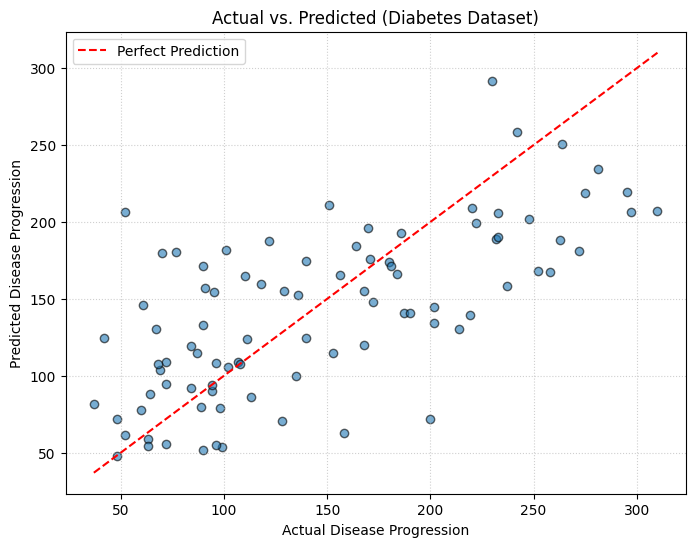

In [31]:
# Define plot bounds
lims = [y_test.min(), y_test.max()]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k')
plt.plot(lims, lims, 'r--', label="Perfect Prediction")

# Labels & Style
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Actual vs. Predicted (Diabetes Dataset)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()